# Inference Cell Segmentation

## Download the checkpoint and set the working directory

Run this notebook inside a cloned CelloType repository. The setup cell finds the repository root, downloads the checkpoint from [Zenodo](https://doi.org/10.5281/zenodo.22736357) (about 2.68 GB), and verifies its SHA-256 checksum. Existing verified files are reused, and interrupted downloads can be resumed by rerunning the cell. The example image is already included in `data/example/`; no dataset ZIP is needed.

From a terminal in the repository root, the equivalent command is:

```bash
python download.py tissuenet_model_0019999.pth
```

See the [download guide](https://cellotype.readthedocs.io/en/latest/downloads.html) for all model weights, datasets, direct links, Python usage, and file-specific licenses.

In [ ]:
from pathlib import Path
import os
import sys

repo_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
                  if (p / "download.py").is_file() and (p / "configs").is_dir()), None)
if repo_root is None:
    raise RuntimeError("Open this notebook inside the cloned CelloType repository.")
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))
from download import download_asset
model_path = download_asset("tissuenet_model_0019999.pth", output_root=repo_root)

In [1]:
from skimage import io
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from cellotype.predict import CelloTypePredictor

## Load the image

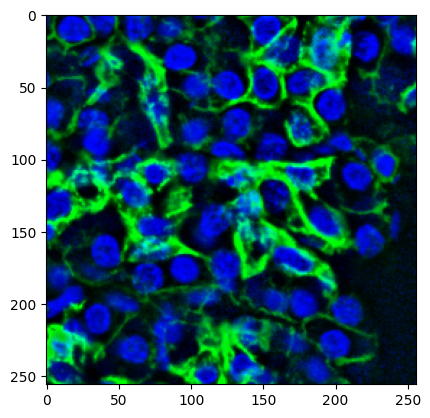

In [3]:
img = io.imread('data/example/example_tissuenet.png')
plt.imshow(img)

## Load the pretrained model and make predictions

In [ ]:
model = CelloTypePredictor(str(model_path),confidence_thresh=0.3, max_det=1000, device='cuda', 
                           config_path='configs/maskdino_R50_bs16_50ep_4s_dowsample1_2048.yaml')

In [5]:
mask = model.predict(img)

## Visualize the results using DeepCell library

In [6]:
from deepcell.utils.plot_utils import create_rgb_image
from deepcell.utils.plot_utils import make_outline_overlay

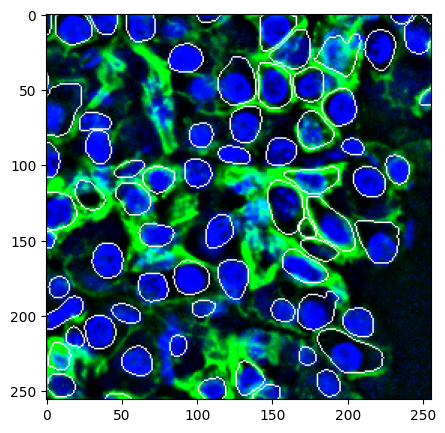

In [7]:
img_data = img[:,:,[2,1]]
img_data = np.reshape(img_data, (1, img_data.shape[0], img_data.shape[1], 2))
rgb_image = create_rgb_image(img_data, channel_colors=['blue', 'green'])
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111)
ax.imshow(make_outline_overlay(rgb_image, predictions=np.reshape(mask, (1, mask.shape[0], mask.shape[1], 1)))[0])